# Assignment 2

**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, LLMs, Prompting

### Setup and Dependencies

In [ ]:
%pip -q install -U transformers accelerate bitsandbytes

In [ ]:
import pandas as pd
import numpy as np
import torch
import time
import random
import re
import gc
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from accelerate import Accelerator

### Huggingface Login

In [ ]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `hf auth whoami` to get more information or `hf auth logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: fineGrained).
The tok

### Data Loading

#### Loading Test set

In [ ]:
test_df = pd.read_csv('data/a2_test.csv')
test_df.head()
cols = test_df.columns.tolist()
cols_formatted = ", ".join(cols[:-1]) + " and " + cols[-1]
print(f"The test set has {test_df.shape[0]} rows and each row has {cols_formatted} columns.")
print('The categories are: ',test_df['label_category'].unique())
print("Each category has the following counts: ",test_df['label_category'].value_counts())

label_to_id = {
    "not-sexist": 0,
    "threats": 1,
    "derogation": 2,
    "animosity": 3,
    "prejudiced": 4,
}

test_texts = test_df["text"].tolist()
test_labels = test_df["label_category"].map(label_to_id).tolist()

print("Label Mapping Strategy:")
for label, id_val in label_to_id.items():
    print(f"  • '{label}' mapped to ID: {id_val}")


The test set has 300 rows and each row has rewire_id, text and label_category columns.
The categories are:  ['derogation' 'prejudiced' 'animosity' 'not-sexist' 'threats']
Each category has the following counts:  label_category
derogation    60
prejudiced    60
animosity     60
not-sexist    60
threats       60
Name: count, dtype: int64
Label Mapping Strategy:
  • 'not-sexist' mapped to ID: 0
  • 'threats' mapped to ID: 1
  • 'derogation' mapped to ID: 2
  • 'animosity' mapped to ID: 3
  • 'prejudiced' mapped to ID: 4


## 1. Model setup


In [ ]:
accelerator = Accelerator()
device = accelerator.device
num_per_class = 3

def free_memory():
    gc.collect()
    accelerator.free_memory()

### 1.1 Model loading

In [ ]:
MODEL_CONFIGS = [
    {
        "name": "microsoft/Phi-3-mini-4k-instruct",
        "nickname": "Phi3Mini"
    },

    {
        "name": "Qwen/Qwen3-1.7B",
        "nickname": "Qwen3"
    }
]

### 1.2 Model Quantization

In [ ]:
def load_model(model_name: str):
    """
    Loads a Language Model with device-specific optimization:
    - CUDA: 4-bit quantization via bitsandbytes
    - MPS: float16 weights (bnb quantization not supported reliably)
    - CPU: float32 weights
    Returns: (model, tokenizer)
    """

    bnb_config = None
    device_map = None
    torch_dtype = torch.float32

    if device.type == "cuda":
        torch_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch_dtype,
        )
        device_map = "auto"

    elif device.type == "mps":
        torch_dtype = torch.float16


    model_kwargs = dict(
        quantization_config=bnb_config,
        torch_dtype=torch_dtype,
        device_map=device_map,
        trust_remote_code=False,
        low_cpu_mem_usage=True,
    )

    model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs)

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=False,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    model.config.pad_token_id = tokenizer.pad_token_id

    if bnb_config is None:
        model.to(device)
    model.eval()
    return model, tokenizer


## 2. Prompt setup

### 2.1 Zero-shot Prompt template

In [ ]:
zero_shot_prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        TEXT: {text}

        ANSWER:
        """
    }
]

### 2.2 Prepare prompts

In [ ]:
def prepare_zero_shot_prompts(texts, prompt_template, tokenizer):
    """
    Task:
    Format input text samples into instructions prompts.

    Inputs:
      texts: list[str] input texts to classify via prompting
      prompt_template: the prompt template provided(list of role/content dicts)
      tokenizer: the transformers Tokenizer object instance associated
      with the chosen model card

      examples: optional. Either:
        - None (zero-shot)
        - str (same examples prepended for every text)
        - list[str] (one examples string per text)

    Output:
      list[str] instruction prompts ready to pass to the model
    """

    formatted_prompts = []

    has_chat_template = (
        hasattr(tokenizer, "apply_chat_template")
        and getattr(tokenizer, "chat_template", None) is not None
    )

    for text in texts:
        current_prompt = copy.deepcopy(prompt_template)

        for message in current_prompt:
            if message['role'] == 'user':
                message['content'] = message['content'].format(text=text.strip())

        if has_chat_template:
            try:
                formatted = tokenizer.apply_chat_template(
                    current_prompt,
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=False,
                )
            except TypeError:
                formatted = tokenizer.apply_chat_template(
                    current_prompt,
                    tokenize=False,
                    add_generation_prompt=True
                )

        else:
            parts = []
            for msg in current_prompt:
                parts.append(f"{msg['role'].upper()}:\n{msg['content'].strip()}\n")
            formatted = "\n".join(parts)

        formatted_prompts.append(formatted)

    return formatted_prompts

## 3. Inference

### 3.1 Generate responses

In [ ]:
def generate_responses(model, tokenizer, prompt_examples, batch_size=4, max_new_tokens=20, max_length=2048):
    """
    Task:
    Make an Inference loop for the model: prompt the LLM model with each
    pre-processed sample and generate responses.

    Inputs:
      model: LLM model instance
      tokenizer: tokenizer associated with this model
      prompt_examples: list[str] prompts (already pre-processed)

    Outputs:
      list[str] generated responses
    """
    all_responses = []

    for i in range(0, len(prompt_examples), batch_size):
        batch_prompts = prompt_examples[i:i + batch_size]

        enc = tokenizer(
            batch_prompts,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
            padding=True,
        )

        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.inference_mode():
            generated_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        input_len = enc["input_ids"].shape[1]
        generated_only = generated_ids[:, input_len:]

        responses = tokenizer.batch_decode(generated_only, skip_special_tokens=True)
        all_responses.extend(responses)

    return all_responses


### 3.2 Process responses

In [ ]:
def process_response(response: str) -> int:
    """
    Task:
      Parse LLM model generated responses into a 5-class label id using label_to_id.

    Inputs:
      response: generated response from LLM

    Outputs:
      parsed classification response(Returns -1 if it cannot be parsed)
    """

    r = response.strip().lower()
    r = r.replace("_", "-")
    r = r.replace("not sexist", "not-sexist")
    r = r.replace("prejudiced discussion", "prejudiced")

    if r in label_to_id:
        return label_to_id[r]

    r2 = r.replace(" ", "-")
    if r2 in label_to_id:
        return label_to_id[r2]

    for label, label_id in label_to_id.items():
        pattern = label.replace("-", r"[-\s]?")
        if re.search(rf"\b{pattern}\b", r, flags=re.IGNORECASE):
            return label_id

    if "not-sexist" in r or "not sexist" in r:
        return 0
    if "threat" in r:
        return 1
    if "derogat" in r:
        return 2
    if "animosit" in r:
        return 3
    if "prejudic" in r:
        return 4

    return -1


### Inference

In [ ]:
def inference(model_name: str, model, tokenizer,prompt_template,examples = ""):

    start_time = time.time()

    if(examples == ""):

        prompts = prepare_zero_shot_prompts(
        texts=test_texts,
        prompt_template=prompt_template,
        tokenizer=tokenizer
        )
    else:
      prompts = prepare_prompts(
          texts=test_texts,
          prompt_template=prompt_template,
          tokenizer=tokenizer,
          examples=examples
          )

    responses = generate_responses(model, tokenizer, prompts)
    predictions = [process_response(r) for r in responses]

    elapsed = time.time() - start_time

    return {
        "responses": responses,
        "predictions": predictions,
        "ground_truth": test_labels,
        "inference_time": elapsed
    }

## 4.Metrics

### 4.1 Compute metrics

In [ ]:
def compute_metrics(y_pred, y_true):
    """
    Task:
      Compute accuracy, macro F1-score, and fail-ratio.

    Inputs:
      y_pred: parsed LLM responses
      y_true: ground-truth binary labels

    Outputs:
      dictionary containing desired metrics
    """
    y_pred = np.array(y_pred, dtype=int)
    y_true = np.array(y_true, dtype=int)

    fail_ratio = np.mean(y_pred == -1)

    accuracy = accuracy_score(y_true, y_pred)

    valid_mask = (y_pred != -1)
    y_pred_filtered = y_pred[valid_mask]
    y_true_filtered = y_true[valid_mask]

    macro_f1 = f1_score(
        y_true_filtered,
        y_pred_filtered,
        average="macro",
        labels=[0, 1, 2, 3, 4],
        zero_division=0
    )

    return {
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "fail_ratio": float(fail_ratio),
    }

## 5. Few-shot Inference

### 5.0 Few-shot Prompt template

In [ ]:
few_shot_prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

         EXAMPLES:
         TEXT: **example 1**
         ANSWER: threats
         TEXT: **example 2**
         ANSWER: not-sexist

         TEXT: {text}

        ANSWER:
        """
    }
]

### 5.1 Loading Demonstration Data set


In [ ]:
demo_df = pd.read_csv('data/demonstrations.csv')
demo_df.head()

,rewire_id,text,label_sexist,label_category,label_vector,split
0,sexism2022_english-7417,female egg donors are allowed to be uggo as fu...,sexist,derogation,2.1 descriptive attacks,train
1,sexism2022_english-10155,My girlfriend is mentally retarded. Or if you ...,sexist,derogation,2.1 descriptive attacks,test
2,sexism2022_english-15154,Lock her UP!!!!,sexist,threats,1.2 incitement and encouragement of harm,train
3,sexism2022_english-13387,So you want to live in a world where women are...,sexist,animosity,"3.1 casual use of gendered slurs, profanities,...",dev
4,sexism2022_english-2990,"Special episode of Loomy Does Politics, by pop...",sexist,prejudiced,4.2 supporting systemic discrimination against...,train


### 5.2 Build Few-shot Demonstration

In [ ]:
def build_few_shot_demonstrations(demonstrations, num_per_class=3, seed=25):
    """
    Inputs:
      demonstrations: DataFrame wrapping demonstrations.csv
      num_per_class: number of demonstrations per class

    Outputs:
      list[str] demonstrations to inject into the prompt template
    """
    demonstrations_list = []

    for i in range(200):
        demo_strings = []
        for label_name, group_df in demonstrations.groupby("label_category"):
            n = min(num_per_class, len(group_df))
            sampled = group_df.sample(n=n, random_state=seed + i)

            for _, row in sampled.iterrows():
                text = str(row['text']).strip()
                label = str(row['label_category']).strip()
                formatted_demo = f"TEXT: {text}\nANSWER: {label}"
                demo_strings.append(formatted_demo)

        demo_block = "\n\n".join(demo_strings)
        demonstrations_list.append(demo_block)

    rng = random.Random(seed)
    rng.shuffle(demonstrations_list)

    return demonstrations_list

In [ ]:
few_shot_examples = build_few_shot_demonstrations(demo_df)
print("Few-shot examples preview:\n")
print(few_shot_examples[0])

Few-shot examples preview:

TEXT: Is this ride fun for them, is this there idea of fun? Because ita fucking not. Its beyond absurd. A media fucking merry-go-round that makes us all look like twats is not my idea of fun.
ANSWER: animosity

TEXT: They believe saying, "Well, I'd have sex with you," is the ultimate proof that a woman can't be incel. It unironically is.
ANSWER: animosity

TEXT: Primate sex is uber-rapey, some manifestations of estrus aside. Why do you think that women will often orgasm when being raped? It's a biological defense mechanism to reduce damage and facilitate pregnancy. Nature is a motherfucker
ANSWER: animosity

TEXT: Dumb Nazi Nigger cunt too stupid to understand her 88 is holding back her 14. They must all secretly love Jews because they're doing the Mossad's work for them for free.
ANSWER: derogation

TEXT: Women who has had many sexual partners: dirty slut who rides the cock carousel, how dare she? Men who sleep around: dominant alpha male guys other men put

### 5.3 Modify prepare_prompts:

In [ ]:
def prepare_prompts(texts, prompt_template, tokenizer, examples=None):
    """
    Task:
    Format input text samples into instructions prompts.

    Inputs:
      texts: list[str] input texts to classify via prompting
      prompt_template: the prompt template provided(list of role/content dicts)
      tokenizer: the transformers Tokenizer object instance associated
      with the chosen model card

      examples: optional. Either:
        - None (zero-shot)
        - str (same examples prepended for every text)
        - list[str] (one examples string per text)

    Output:
      list[str] instruction prompts ready to pass to the model
    """

    formatted_prompts = []

    def get_examples(i):
        if examples and len(examples) > 0 and isinstance(examples, (list, tuple)):
            safe_index = i % len(examples)
            ex_str = examples[safe_index]
            return examples[safe_index]
        else:
            return ""

    has_chat_template = (
        hasattr(tokenizer, "apply_chat_template")
        and getattr(tokenizer, "chat_template", None) is not None
    )


    for i,text in enumerate(texts):
        ex = get_examples(i)
        current_prompt = copy.deepcopy(prompt_template)

        for message in current_prompt:
            if message['role'] == 'user':
                message['content'] = message['content'].format(
                    text=text.strip(),
                    examples=ex
                    )

        if has_chat_template:
            try:
                formatted = tokenizer.apply_chat_template(
                    current_prompt,
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=False,
                )
            except TypeError:
                formatted = tokenizer.apply_chat_template(
                    current_prompt,
                    tokenize=False,
                    add_generation_prompt=True
                )

        else:
            parts = []
            for msg in current_prompt:
                parts.append(f"{msg['role'].upper()}:\n{msg['content'].strip()}\n")
            formatted = "\n".join(parts)

        formatted_prompts.append(formatted)

    return formatted_prompts

## 6. Error Analysis

In [ ]:
id2label = {v: k for k, v in label_to_id.items()}
LABEL_IDS = [0, 1, 2, 3, 4]
LABEL_NAMES = [id2label[i] for i in LABEL_IDS]

### 6.1 Performance table

In [ ]:
def performance_table():
  rows = []
  for model_name, tasks in model_results.items():

      for task_type, task_data in tasks.items():
          rows.append({
              "Model": model_name,
              "Setting": task_type,
              "Accuracy": task_data["metrics"].get("accuracy", 0),
              "Macro F1": task_data["metrics"].get("macro_f1", 0),
              "Fail Ratio": task_data["metrics"].get("fail_ratio", 0),
              "Inference Time (s)": task_data["inference_time"]
          })

  df_results = pd.DataFrame(rows)
  df_results = df_results.sort_values(by=["Model", "Setting"]).reset_index(drop=True)

  print(df_results)

### 6.2 Confusion Matrix

In [ ]:
def plot_confusion_matrix(results, title):
    y_true = np.array(results["ground_truth"], dtype=int)
    y_pred = np.array(results["predictions"], dtype=int)

    fail_ratio = np.mean(y_pred == -1)
    y_pred_eval = y_pred.copy()
    y_pred_eval[y_pred_eval == -1] = 0

    cm = confusion_matrix(y_true, y_pred_eval, labels=LABEL_IDS)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{title} (fail={fail_ratio:.1%})")
    plt.colorbar()
    tick_marks = np.arange(len(LABEL_NAMES))
    plt.xticks(tick_marks, LABEL_NAMES, rotation=45, ha="right")
    plt.yticks(tick_marks, LABEL_NAMES)

    thresh = cm.max() * 0.6 if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            plt.text(j, i, str(val),
                     ha="center", va="center",
                     color="white" if val > thresh else "black")

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

In [ ]:
def nll_true_label_for_samples(model, tokenizer, prompts, true_label_ids, max_length=2048):
    """
    Compute per-sample NLL of the true label string given the prompt.
    Returns an array of NLL values aligned with prompts.
    """
    true_label_strs = [id2label[int(i)] for i in true_label_ids]

    nll = np.zeros(len(prompts), dtype=float)

    for lbl in LABEL_NAMES:
        idx = [i for i, t in enumerate(true_label_strs) if t == lbl]
        if not idx:
            continue

        sub_prompts = [prompts[i] for i in idx]

        enc = tokenizer(
            sub_prompts,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
            padding=True,
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        label_ids = tokenizer(lbl, add_special_tokens=False)["input_ids"]
        label_ids = torch.tensor(label_ids, dtype=torch.long, device=device)

        with torch.inference_mode():
            for b in range(enc["input_ids"].shape[0]):
                input_ids = enc["input_ids"][b]
                attn = enc["attention_mask"][b]
                prompt_len = int(attn.sum().item())
                prompt_ids = input_ids[:prompt_len]

                full_ids = torch.cat([prompt_ids, label_ids], dim=0).unsqueeze(0)
                out = model(full_ids)
                logits = out.logits
                log_probs = torch.log_softmax(logits, dim=-1)

                this_nll = 0.0
                for t, tok_id in enumerate(label_ids):
                    pos = prompt_len + t - 1
                    this_nll -= float(log_probs[0, pos, tok_id].item())

                nll[idx[b]] = this_nll

    return nll

In [ ]:
def error_analysis_from_existing_results(model_name, model, tokenizer, results, prompt_template, examples=None, setting="zero-shot", top_k=10):
    """
    Uses already-generated predictions/responses from `results`,
    and only adds a dataframe + NLL-based top errors.
    """
    prompts = prepare_prompts(test_texts, prompt_template, tokenizer, examples=examples)

    y_true = np.array(results["ground_truth"], dtype=int)
    raw_pred = np.array(results["predictions"], dtype=int)
    y_pred_eval = raw_pred.copy()
    y_pred_eval[y_pred_eval == -1] = 0

    df = pd.DataFrame({
        "text": test_texts,
        "true_id": y_true,
        "pred_id": y_pred_eval,
        "raw_pred_id": raw_pred,
        "raw_response": results["responses"]
    })
    df["true_label"] = df["true_id"].map(id2label)
    df["pred_label"] = df["pred_id"].map(id2label)
    df["is_fail"] = (df["raw_pred_id"] == -1)

    df["nll_true_label"] = nll_true_label_for_samples(model, tokenizer, prompts, y_true)

    wrong = df[df["true_id"] != df["pred_id"]].copy()
    top_errors = wrong.sort_values("nll_true_label", ascending=False).head(top_k)

    return {
        "df": df,
        "top_errors": top_errors
    }

### Master pipeline

In [ ]:
model_results = {}
analysis_outputs = {}
metrics = {}

print("Starting Master Pipeline...")

for cfg in MODEL_CONFIGS:
  nickname = cfg["nickname"]
  model_name = cfg["name"]

  print("\n" + "="*60)
  print(f"Processing{nickname}...")
  print("="*60)

  model,tokenizer = load_model(model_name)

  print("\n" + "="*60)
  print(f"{nickname} Loaded")

  model_results[nickname] = {}

  model_results[nickname]['zero_shot'] = inference(model_name, model,tokenizer,zero_shot_prompt)
  model_results[nickname]['few_shot'] = inference(model_name, model,tokenizer,few_shot_prompt,few_shot_examples)

  model_results[nickname]['zero_shot']["metrics"] = compute_metrics(model_results[nickname]['zero_shot']["predictions"],model_results[nickname]['zero_shot']["ground_truth"])
  model_results[nickname]['few_shot']["metrics"] = compute_metrics(model_results[nickname]['few_shot']["predictions"],model_results[nickname]['few_shot']["ground_truth"])

  model_results[nickname]['zero_shot']["error_analysis"] = error_analysis_from_existing_results(
        model_name=nickname,
        model=model,
        tokenizer=tokenizer,
        results=model_results[nickname]["zero_shot"],
        prompt_template=zero_shot_prompt,
        examples=None,
        setting="zero-shot",
        top_k=10
    )

  model_results[nickname]['few_shot']["error_analysis"] = error_analysis_from_existing_results(
        model_name=nickname,
        model=model,
        tokenizer=tokenizer,
        results=model_results[nickname]["few_shot"],
        prompt_template=few_shot_prompt,
        examples=few_shot_examples,
        setting="few-shot",
        top_k=10
    )

  del model
  del tokenizer
  free_memory()

Starting Master Pipeline...


ProcessingPhi3Mini...


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Qwen3 Loaded


In [ ]:
def show_results():
    nickname1 = MODEL_CONFIGS[0]["nickname"]
    model_name1 = MODEL_CONFIGS[0]["name"]

    nickname2 = MODEL_CONFIGS[1]["nickname"]
    model_name2 = MODEL_CONFIGS[1]["name"]

    print("\n" + "="*60)
    print(f"✓ {nickname1} zero shot inference completed in {model_results[nickname1]['zero_shot']["inference_time"]:.2f}s (avg {model_results[nickname1]['zero_shot']["inference_time"]/len(test_texts):.3f}s/sample)")
    print("\n" + "="*60)
    print(f"✓ {nickname2} zero shot inference completed in {model_results[nickname2]['zero_shot']["inference_time"]:.2f}s (avg {model_results[nickname2]['zero_shot']["inference_time"]/len(test_texts):.3f}s/sample)")
    print("="*60)

    print("\n" + "="*60)
    print(f"✓ {nickname1} few shot inference completed in {model_results[nickname1]['few_shot']["inference_time"]:.2f}s (avg {model_results[nickname1]['few_shot']["inference_time"]/len(test_texts):.3f}s/sample)")
    print("\n" + "="*60)
    print(f"✓ {nickname2} few shot inference completed in {model_results[nickname2]['few_shot']["inference_time"]:.2f}s (avg {model_results[nickname2]['few_shot']["inference_time"]/len(test_texts):.3f}s/sample)")
    print("="*60)

    plot_confusion_matrix(model_results[nickname1]['zero_shot'], f"{nickname1} — zero_shot")
    plot_confusion_matrix(model_results[nickname2]['zero_shot'], f"{nickname2} — zero_shot")

    plot_confusion_matrix(model_results[nickname1]['few_shot'], f"{nickname1} — few_shot")
    plot_confusion_matrix(model_results[nickname2]['few_shot'], f"{nickname2} — few_shot")


    print("\n" + "="*60)
    print(f"{nickname1} — zero_shot")
    print("="*60)

    df1_zero = model_results[nickname1]['zero_shot']["error_analysis"]["df"]
    df2_zero = model_results[nickname2]['zero_shot']["error_analysis"]["df"]

    print(f"Fails: {df1_zero['is_fail'].mean():.3f} | Wrong: {(df1_zero['true_id'] != df1_zero['pred_id']).mean():.3f}")
    print("\n" + "="*60)
    print(f"Fails: {df2_zero['is_fail'].mean():.3f} | Wrong: {(df2_zero['true_id'] != df2_zero['pred_id']).mean():.3f}")
    print("\n" + "="*60)

    df1_few = model_results[nickname1]['few_shot']["error_analysis"]["df"]
    df2_few = model_results[nickname2]['few_shot']["error_analysis"]["df"]

    print(f"Fails: {df1_few['is_fail'].mean():.3f} | Wrong: {(df1_few['true_id'] != df1_few['pred_id']).mean():.3f}")
    print("\n" + "="*60)
    print(f"Fails: {df2_few['is_fail'].mean():.3f} | Wrong: {(df2_few['true_id'] != df2_few['pred_id']).mean():.3f}")
    print("\n" + "="*60)

    top_errors1_zero = model_results[nickname1]['zero_shot']["error_analysis"]["top_errors"]
    top_errors2_zero = model_results[nickname2]['zero_shot']["error_analysis"]["top_errors"]

    print("\nTop errors (highest NLL of true label):")
    with pd.option_context("display.max_colwidth", None):
        display(top_errors1_zero[["text", "true_label", "pred_label", "raw_response", "nll_true_label"]])
    print("\nTop errors (highest NLL of true label):")
    with pd.option_context("display.max_colwidth", None):
        display(top_errors2_zero[["text", "true_label", "pred_label", "raw_response", "nll_true_label"]])

    top_errors1_few = model_results[nickname1]['few_shot']["error_analysis"]["top_errors"]
    top_errors2_few = model_results[nickname2]['few_shot']["error_analysis"]["top_errors"]

    print("\nTop errors (highest NLL of true label):")
    with pd.option_context("display.max_colwidth", None):
        display(top_errors1_few[["text", "true_label", "pred_label", "raw_response", "nll_true_label"]])

    print("\nTop errors (highest NLL of true label):")
    with pd.option_context("display.max_colwidth", None):
        display(top_errors2_few[["text", "true_label", "pred_label", "raw_response", "nll_true_label"]])

    print("\n" + "="*60)
    performance_table()

Showing Results...



✓ Phi3Mini zero shot inference completed in 32.01s (avg 0.107s/sample)

✓ Qwen3 zero shot inference completed in 29.68s (avg 0.099s/sample)

✓ Phi3Mini few shot inference completed in 29.67s (avg 0.099s/sample)

✓ Qwen3 few shot inference completed in 31.37s (avg 0.105s/sample)


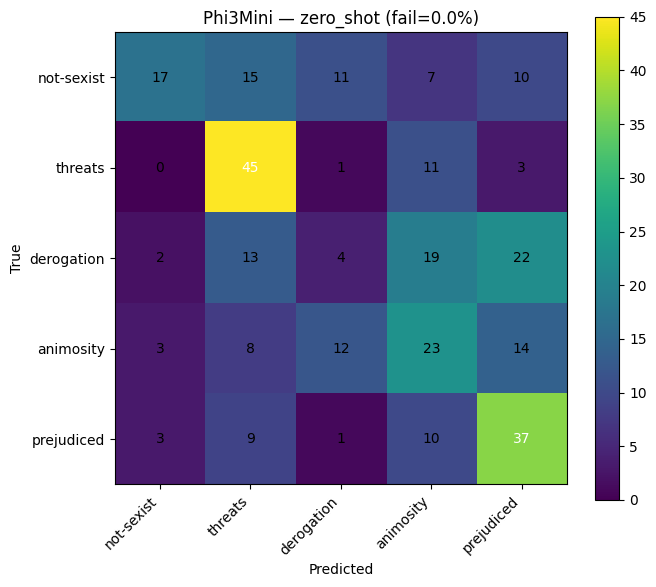

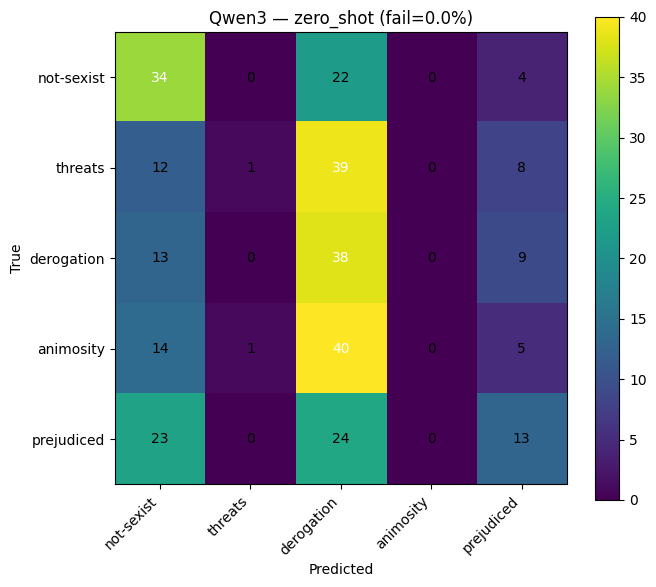

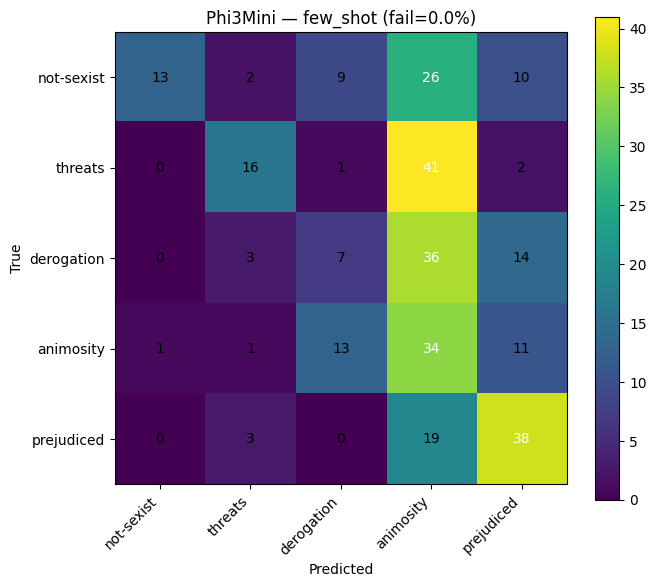

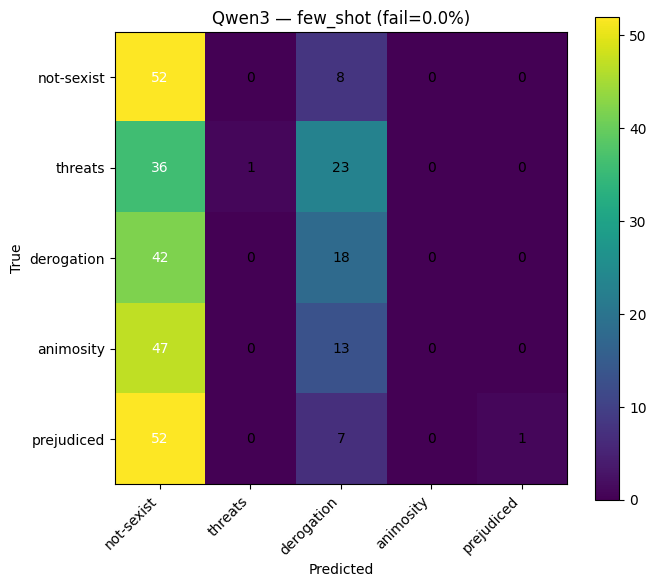


Phi3Mini — zero_shot
Fails: 0.000 | Wrong: 0.580

Fails: 0.000 | Wrong: 0.713

Fails: 0.000 | Wrong: 0.640

Fails: 0.000 | Wrong: 0.760


Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
190,"In vitro fertilization. Even if it's a terrible idea for the child's development, a woman with baby rabies doesn't give a shit. We'll see what happens. Crushing birth control pills in her drinks is a good option.",threats,animosity,animosity,39.501587
126,"Let’s make an all female cast star wars movie, directed by Paul Feig, starring the cast of the 2016 ’blockbuster’ hit Ghostbusters! It’s Ghostbusters.. in space, with like lasers and stronk whamen & stuff.",animosity,prejudiced,prejudiced,39.009383
85,"dudes are tripping when they say an escort would be safer. These bitches suck 10+ daily, have random dudes fingers in their pussies, do bareback with some clients (no exagerration). no way an escort is safer than a non escort IMO",derogation,animosity,animosity,38.516052
80,"Who's cock is she sucking? If it's not yours she is not interested, period.",derogation,threats,threats,35.375000
195,"maybe in the old days girls like this would be worth it because they were virgins, weren't hoes, were loyal, didn't go out to bars and didn't cheat. But the ""modern woman"" who ""explores her sexuality""? Hell no. That's worthless",derogation,animosity,animosity,34.505875
183,well..well..well.. what do we have here. The dumbest motherfucker to ever serve in congress just revealed state secrets live at her press conference. Hang this fucking traitor. [URL],threats,animosity,animosity,31.804688
191,"#BritFam Brit HIGH court recognizes Sharia Marriage, but only so wife can divorce rape husbands a$$ets case of leftists choosing the path which screwed a man, more than leftists trying to recognize Sharia [USER] [USER] [URL]",prejudiced,animosity,animosity,27.757355
286,To rationalize being an arrogant selfish prick.,not-sexist,threats,threats,27.248047
117,"If the mother had an ~~fortunate~~ unfortunate accident, it would be a real shame.",threats,derogation,derogation,26.389709
271,It's so easy. Just have a vagina at birth and you'll be treated like a princess for life.,derogation,prejudiced,prejudiced,25.992188



Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
222,"Like with the beautiful women who never knew life was cruel. Incels can’t comprehend that women and sex are not the prize. Even women know that men are the prize. From controlling and enslaving men, is the only way women get power and wealth.",derogation,prejudiced,prejudiced,79.000000
196,"He's got it backwards, we need STRONG men and GOOD women.",animosity,derogation,derogation,62.125000
116,"It's why we dress women up, romanticize and idealize them, etc. All of it obscures the ugly truth of it. And so long as you have functioning monogamous marriage, men never have to know better. Nobody benefits more than women themselves.",prejudiced,not-sexist,not-sexist,55.127991
193,"""Why women the size of whales shouldn't be allowed to drive"" by [USER] [URL]",derogation,not-sexist,not-sexist,51.511230
254,40 years of your fat mom on welfare is reparations you lazy low iq bitch,derogation,not-sexist,not-sexist,50.812504
278,"White men letting groids, juice, and women run wild was the beginning of the end.",derogation,not-sexist,not-sexist,50.812504
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,prejudiced,prejudiced,49.509094
98,[USER] Science will have to invent a new form of math just to quantify her ego. Maybe under a president Trump the only place she'll be leaving to is a prison. Let her bitch about the patriarchy from cell block C.,animosity,derogation,derogation,48.990234
53,Kurds are drug addict commies and there is no way they wouldn’t molest a white girl.,not-sexist,derogation,derogation,48.625232
256,3 hot girls and you think of fecal toilet comments! You must be a jew. SMDH,not-sexist,derogation,derogation,48.625149



Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
271,It's so easy. Just have a vagina at birth and you'll be treated like a princess for life.,derogation,animosity,animosity,34.103027
31,"If she's fucking you, she likes you.",not-sexist,animosity,animosity,32.545898
183,well..well..well.. what do we have here. The dumbest motherfucker to ever serve in congress just revealed state secrets live at her press conference. Hang this fucking traitor. [URL],threats,animosity,animosity,31.863281
77,63% of girls with dogs also have sex with dogs.,derogation,animosity,animosity,31.843750
174,Sell that bitch a dream...then ghost her ass.,derogation,animosity,animosity,31.843750
190,"In vitro fertilization. Even if it's a terrible idea for the child's development, a woman with baby rabies doesn't give a shit. We'll see what happens. Crushing birth control pills in her drinks is a good option.",threats,animosity,animosity,30.389038
126,"Let’s make an all female cast star wars movie, directed by Paul Feig, starring the cast of the 2016 ’blockbuster’ hit Ghostbusters! It’s Ghostbusters.. in space, with like lasers and stronk whamen & stuff.",animosity,prejudiced,prejudiced,30.292336
35,"That's because black women are more overweight, less feminine, and bitchier on average",derogation,prejudiced,prejudiced,27.797852
267,I never thought women would be so happen to kill their offspring. It's just amazing.,derogation,animosity,animosity,27.797852
278,"White men letting groids, juice, and women run wild was the beginning of the end.",derogation,prejudiced,prejudiced,27.797852



Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
222,"Like with the beautiful women who never knew life was cruel. Incels can’t comprehend that women and sex are not the prize. Even women know that men are the prize. From controlling and enslaving men, is the only way women get power and wealth.",derogation,not-sexist,not-sexist,77.500000
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,not-sexist,not-sexist,57.004608
98,[USER] Science will have to invent a new form of math just to quantify her ego. Maybe under a president Trump the only place she'll be leaving to is a prison. Let her bitch about the patriarchy from cell block C.,animosity,not-sexist,not-sexist,55.551025
29,"Do yourself a favor. Dont dignify a thing,by callin it a she.👍Thats a fuckin abomimation.",not-sexist,derogation,derogation,53.753448
240,#Politics #GabFam #MAGA #Australia As #MSM develops a case of total silence while covering womens virtue signaling BS. Must've been the vagina hats rather than the FGM and child RAPES [URL],derogation,not-sexist,not-sexist,49.501518
140,White progressive women can be oppressed and have supremacy... simultaneously... now that's a damn privilege,prejudiced,not-sexist,not-sexist,46.502177
165,It's part of the gynocentric society's effort to abolish all standards for women.,prejudiced,not-sexist,not-sexist,46.502177
131,It’s different if you’re a woman. Spreading your legs just gives you sex,animosity,derogation,derogation,46.251144
116,"It's why we dress women up, romanticize and idealize them, etc. All of it obscures the ugly truth of it. And so long as you have functioning monogamous marriage, men never have to know better. Nobody benefits more than women themselves.",prejudiced,not-sexist,not-sexist,46.251129
111,"Yes, because she made a mistake,she SHOULD pay for it. It was her mistake not society's. I'm all for legit help for someone in need but people who fuck around, don't use protection and then expect to get bailed out can go screw",prejudiced,not-sexist,not-sexist,46.126183



      Model    Setting  Accuracy  Macro F1  Fail Ratio  Inference Time (s)
0  Phi3Mini   few_shot  0.360000  0.352231         0.0           29.667027
1  Phi3Mini  zero_shot  0.420000  0.390117         0.0           32.013189
2     Qwen3   few_shot  0.240000  0.140901         0.0           31.370517
3     Qwen3  zero_shot  0.286667  0.214318         0.0           29.678943


In [ ]:
print("Showing Results...\n")
print("\n" + "="*60)
show_results()

# Error Analysis Report (LLM Prompting)

## 0. Experimental Setup (What we analyze)
- **Task:** 5-class sexism type classification
- **Test set:** 300 samples, **balanced** (60 per class): `not-sexist`, `threats`, `derogation`, `animosity`, `prejudiced`
- **Models / settings:** Phi3Mini, Qwen3 — each in **zero-shot** and **few-shot**
- **Parsing robustness:** Fail ratio is **0.00** for all runs → errors are mostly **semantic misclassification**, not formatting.

### Quantitative Summary (from the notebook)
| Model | Setting | Accuracy | Macro-F1 | Fail Ratio | Inference Time (s) |
|---|---|---:|---:|---:|---:|
| Phi3Mini | zero-shot | **0.4200** | **0.3901** | 0.0000 | 32.01 |
| Phi3Mini | few-shot | 0.3600 | 0.3522 | 0.0000 | 29.67 |
| Qwen3 | zero-shot | 0.2867 | 0.2143 | 0.0000 | 29.68 |
| Qwen3 | few-shot | 0.2400 | 0.1409 | 0.0000 | 31.37 |

**Key takeaways**
- **Best run:** Phi3Mini **zero-shot** (0.42 Acc / 0.39 Macro-F1).
- **Few-shot hurts** both models (especially Qwen3), suggesting the demonstrations introduced bias rather than clarifying label boundaries.
- Since the test set is balanced across 5 classes, a naive baseline is around **0.20 accuracy** → Phi3Mini is meaningfully above baseline, while Qwen3 is only moderately above it.

---

## 1. Error Analysis Method (How “Top Errors” are defined)
We rank mistakes using the **negative log-likelihood (NLL) of the true label** (`nll_true_label`):
- **High NLL + wrong label = confidently wrong** → these examples are the most informative for diagnosing systematic failure modes.
- **Low NLL + wrong label = borderline** → these often reflect genuine ambiguity.

---

## 2. Common Error Patterns (Across models)

### A) Overlap between `threats`, `derogation`, and `animosity`
These categories often share similar surface cues (aggression, insults, hostile tone), so models confuse them:
- `threats → animosity` when harm intent is **implicit** rather than explicit.
- `derogation → animosity` when degrading language is read as generic hostility.

### B) `prejudiced` is frequently missed (implicit ideology / “reasonable framing”)
`prejudiced` often appears as “normal-sounding” statements supporting discrimination or traditional roles.  
Both models—especially **Qwen3**—tend to label these as `not-sexist` unless the wording contains obvious hate markers.

### C) False positives from profanity or aggression without sexism
Some `not-sexist` tweets contain profanity or aggressive tone not aimed at women.  
Models may over-associate toxicity with sexism and predict `derogation` or `animosity`.

---

## 3. Model-by-Model Findings

### 3.1 Phi3Mini (zero-shot) — Best run
**Main failure mode:** category collapse into `animosity`  
- Common swaps: `threats → animosity`, `derogation → animosity`

**Interpretation**
- Phi3Mini usually recognizes hostile/sexist content but struggles with fine-grained boundaries.
- When harm is implied (not explicit), it often predicts `animosity` instead of `threats`.

---

### 3.2 Qwen3 (zero-shot)
**Main failure mode:** under-detecting implicit sexism → predicting `not-sexist`
- Common swaps: `derogation → not-sexist`, `prejudiced → not-sexist`

**Interpretation**
- Qwen3 appears more conservative unless the sexism is explicit.
- When it flags sexism, it sometimes defaults to `derogation`, suggesting a rough “toxicity ⇒ derogation” heuristic.

---

### 3.3 Phi3Mini (few-shot)
**What changes:** performance drops vs zero-shot  
**Main failure mode:** stronger bias toward predicting `animosity`
- Common swaps: `derogation → animosity`, `threats → animosity`
- Some false positives: `not-sexist → animosity`

**Interpretation**
- The few-shot examples likely primed the model toward the “hostile insult” pattern, making it overuse `animosity`.
- Few-shot increased pattern-matching behavior rather than improving rule-based distinction.

---

### 3.4 Qwen3 (few-shot) — Worst run
**Main failure mode:** major collapse into `not-sexist`
- Common swaps: `prejudiced → not-sexist` (frequent), plus `derogation/animosity → not-sexist`

**Interpretation**
- Few-shot likely made Qwen3 rely heavily on similarity to the demonstrations.
- If sexism is implicit (especially `prejudiced`), Qwen3 often defaults to `not-sexist`, producing very low Macro-F1.

---

## 4. Why Few-Shot Did Not Help (and often hurt)
Likely causes:
1. **Demo bias / style mismatch:** extreme or overly specific demonstrations encourage pattern matching.
2. **Overlapping definitions:** examples don’t resolve fine boundaries between `threats` / `derogation` / `animosity`.
3. **Instruction dilution:** longer prompts weaken adherence to the label definitions.

---

## 5. Suggested Improvements

1. **Add explicit boundary rules inside the prompt**
   - `threats`: explicit intent/desire for harm or coercion  
   - `animosity`: direct hostile insults targeting women  
   - `derogation`: degrading/objectifying descriptions of women  
   - `prejudiced`: justification/support for discrimination or restrictive roles

2. **Use fewer but cleaner few-shot demonstrations**
   - Keep examples short, unambiguous, and definition-matched (even 1 per class can help).

3. **Forced-choice scoring instead of free generation**
   - Compute NLL for each candidate label and choose the lowest-NLL label.
   - This improves consistency and reduces generation quirks.

4. **Hierarchical classification**
   - Stage 1: `not-sexist` vs `sexist`
   - Stage 2: if sexist → classify into `{threats, derogation, animosity, prejudiced}`
   - Often improves both false positives and fine-grained discrimination.